In [1]:
from google.colab import files
import os

print("Select your downloaded zip file:")
uploaded = files.upload()

# Get the uploaded filename automatically
zip_filename = list(uploaded.keys())[0]
print(f"Uploaded: {zip_filename}")

Select your downloaded zip file:


Saving Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv.zip to Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv.zip
Saving Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv.zip to Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv.zip
Saving Friday-WorkingHours-Morning.pcap_ISCX.csv.zip to Friday-WorkingHours-Morning.pcap_ISCX.csv.zip
Uploaded: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv.zip


In [2]:
import zipfile
import glob
import os
import pandas as pd
import numpy as np

# 1. Unzip all three zip files into dataset/
target_dir = "dataset"
os.makedirs(target_dir, exist_ok=True)

zip_files = glob.glob("*.zip")
print(f"Extracting {len(zip_files)} zip archives...")

for z in zip_files:
    with zipfile.ZipFile(z, 'r') as zip_ref:
        zip_ref.extractall(target_dir)

print("Files extracted into dataset/:")
csv_paths = glob.glob(f"{target_dir}/**/*.csv", recursive=True)
for c in csv_paths:
    print(" -", c)

# 2. Define chronological load order: Morning -> PortScan -> DDoS
load_order = [
    "Morning",
    "PortScan",
    "DDos"
]

ordered_csvs = []
for keyword in load_order:
    for path in csv_paths:
        if keyword.lower() in path.lower() and path not in ordered_csvs:
            ordered_csvs.append(path)

print("\nLoad order to preserve attack progression:")
for p in ordered_csvs:
    print(" ->", p)

# 3. Read and concatenate
dfs = []
for p in ordered_csvs:
    print(f"Loading {os.path.basename(p)}...")
    temp_df = pd.read_csv(p)
    temp_df.columns = temp_df.columns.str.strip()
    dfs.append(temp_df)

df = pd.concat(dfs, ignore_index=True)
print(f"\nTotal raw combined rows: {len(df)}")

# 4. Clean infinite and NaN values
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

# 5. Select 16 core behavioral features
selected_features = [
    'Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
    'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
    'Fwd Packet Length Mean', 'Bwd Packet Length Mean',
    'Flow Bytes/s', 'Flow Packets/s',
    'Flow IAT Mean', 'Flow IAT Std',
    'SYN Flag Count', 'ACK Flag Count', 'RST Flag Count',
    'Init_Win_bytes_forward'
]

# 6. Map to MITRE ATT&CK stages
def map_mitre(label):
    lbl = str(label).upper()
    if 'BENIGN' in lbl:
        return 0  # Normal Baseline
    elif 'PORT' in lbl:
        return 1  # Reconnaissance / Discovery
    elif 'BOT' in lbl:
        return 2  # Command & Control
    elif 'DDOS' in lbl or 'DOS' in lbl:
        return 3  # Impact
    return 0

df['mitre_stage'] = df['Label'].apply(map_mitre)
df['attack_target'] = (df['mitre_stage'] > 0).astype(int)

processed_df = df[selected_features + ['mitre_stage', 'attack_target']].copy()

print("\nData Preparation Complete.")
print(f"Cleaned matrix shape: {processed_df.shape}")
print("\nClass breakdown (0: Normal, 1: Recon, 2: C2, 3: Impact):")
print(processed_df['mitre_stage'].value_counts())

Extracting 3 zip archives...
Files extracted into dataset/:
 - dataset/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
 - dataset/Friday-WorkingHours-Morning.pcap_ISCX.csv
 - dataset/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv

Load order to preserve attack progression:
 -> dataset/Friday-WorkingHours-Morning.pcap_ISCX.csv
 -> dataset/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
 -> dataset/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Loading Friday-WorkingHours-Morning.pcap_ISCX.csv...
Loading Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv...
Loading Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv...

Total raw combined rows: 703245

Data Preparation Complete.
Cleaned matrix shape: (702718, 18)

Class breakdown (0: Normal, 1: Recon, 2: C2, 3: Impact):
mitre_stage
0    413933
1    158804
3    128025
2      1956
Name: count, dtype: int64


In [3]:
from sklearn.preprocessing import StandardScaler
import joblib

# 1. 80/20 chronological split
split_idx = int(len(processed_df) * 0.8)
train_raw = processed_df.iloc[:split_idx]
test_raw = processed_df.iloc[split_idx:]

# 2. Fit scaler ONLY on train set to prevent future data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_raw[selected_features])
X_test_scaled = scaler.transform(test_raw[selected_features])

# Save scaler for Day 4 deployment
joblib.dump(scaler, "scaler.pkl")

# Grab the target labels
y_train_mitre = train_raw['mitre_stage'].values
y_train_attack = train_raw['attack_target'].values

y_test_mitre = test_raw['mitre_stage'].values
y_test_attack = test_raw['attack_target'].values

print(f"Train samples: {len(X_train_scaled)}")
print(f"Test samples:  {len(X_test_scaled)}")
print("Scaler saved as scaler.pkl")

Train samples: 562174
Test samples:  140544
Scaler saved as scaler.pkl


In [4]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np

class NetworkTrajectoryDataset(Dataset):
    def __init__(self, features, mitre_labels, attack_labels, window_size=20, stride=10):
        self.window_size = window_size

        # Calculate indices using the stride to preserve memory
        indices = list(range(0, len(features) - window_size - 1, stride))
        num_samples = len(indices)

        # Pre-allocate numpy arrays
        self.X_seq = np.zeros((num_samples, window_size, features.shape[1]), dtype=np.float32)
        self.y_next_state = np.zeros((num_samples, features.shape[1]), dtype=np.float32)
        self.y_mitre = np.zeros(num_samples, dtype=np.int64)
        self.y_attack = np.zeros(num_samples, dtype=np.float32)

        for i, idx in enumerate(indices):
            self.X_seq[i] = features[idx : idx + window_size]
            self.y_next_state[i] = features[idx + window_size]   # Ground truth S_{t+1}
            self.y_mitre[i] = mitre_labels[idx + window_size]    # Ground truth MITRE stage
            self.y_attack[i] = attack_labels[idx + window_size]  # Ground truth binary flag

    def __len__(self):
        return len(self.X_seq)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.X_seq[idx], dtype=torch.float32),
            torch.tensor(self.y_next_state[idx], dtype=torch.float32),
            torch.tensor(self.y_mitre[idx], dtype=torch.long),
            torch.tensor(self.y_attack[idx], dtype=torch.float32)
        )

print("Constructing sequence tensors...")
train_dataset = NetworkTrajectoryDataset(X_train_scaled, y_train_mitre, y_train_attack, window_size=20, stride=10)
test_dataset = NetworkTrajectoryDataset(X_test_scaled, y_test_mitre, y_test_attack, window_size=20, stride=10)

print(f"Total training sequences: {len(train_dataset)}")
print(f"Total testing sequences:  {len(test_dataset)}")

# PyTorch DataLoaders for batching
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

# Check one batch to verify shape
sample_x, sample_next, sample_mitre, _ = train_dataset[0]
print(f"\nSequence input shape (Window, Features): {sample_x.shape}")
print(f"Next-state target shape: {sample_next.shape}")

Constructing sequence tensors...
Total training sequences: 56216
Total testing sequences:  14053

Sequence input shape (Window, Features): torch.Size([20, 16])
Next-state target shape: torch.Size([16])


In [5]:
import torch
import torch.nn as nn

# Select GPU if available, otherwise fallback to CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Executing on device: {device}")

class NetworkWorldModel(nn.Module):
    def __init__(self, input_dim=16, hidden_dim=64, num_layers=2, num_classes=4):
        super(NetworkWorldModel, self).__init__()

        # 1. Temporal Backbone: Learns sequence dependencies over the 20 time steps
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2 if num_layers > 1 else 0.0
        )

        # 2. Dynamics Head: Predicts the next continuous telemetry vector (S_{t+1})
        self.dynamics_head = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Linear(32, input_dim)   # Outputs the 16 features of the simulated next state
        )

        # 3. MITRE ATT&CK Classification Head: Predicts threat progression stage
        self.classifier_head = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)  # 4 classes (0: Normal, 1: Recon, 2: C2, 3: Impact)
        )

    def forward(self, x):
        # x shape: (batch_size, 20, 16)
        lstm_out, _ = self.lstm(x)

        # Extract the hidden state from the last time step (step 20)
        h_t = lstm_out[:, -1, :]

        # Forward pass through both heads
        pred_next_state = self.dynamics_head(h_t)
        pred_mitre_logits = self.classifier_head(h_t)

        return pred_next_state, pred_mitre_logits

# Instantiate the model
world_model = NetworkWorldModel(input_dim=16, hidden_dim=64, num_layers=2, num_classes=4).to(device)

print("\nModel Architecture:")
print(world_model)

Executing on device: cuda

Model Architecture:
NetworkWorldModel(
  (lstm): LSTM(16, 64, num_layers=2, batch_first=True, dropout=0.2)
  (dynamics_head): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
  )
  (classifier_head): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=4, bias=True)
  )
)


In [6]:
import torch.optim as optim

criterion_dynamics = nn.MSELoss()
criterion_mitre = nn.CrossEntropyLoss()

optimizer = optim.Adam(world_model.parameters(), lr=0.001)
epochs = 5

print(f"Beginning training on {device} for {epochs} epochs...\n")

for epoch in range(epochs):
    world_model.train()
    running_dyn_loss = 0.0
    running_clf_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (batch_x, batch_next, batch_mitre, _) in enumerate(train_loader):
        batch_x = batch_x.to(device)
        batch_next = batch_next.to(device)
        batch_mitre = batch_mitre.to(device)

        optimizer.zero_grad()

        pred_next, pred_mitre = world_model(batch_x)

        loss_dyn = criterion_dynamics(pred_next, batch_next)
        loss_clf = criterion_mitre(pred_mitre, batch_mitre)
        total_loss = loss_dyn + loss_clf

        total_loss.backward()
        optimizer.step()

        running_dyn_loss += loss_dyn.item() * batch_x.size(0)
        running_clf_loss += loss_clf.item() * batch_x.size(0)

        _, predicted_class = torch.max(pred_mitre, 1)
        correct += (predicted_class == batch_mitre).sum().item()
        total += batch_mitre.size(0)

    epoch_dyn = running_dyn_loss / total
    epoch_clf = running_clf_loss / total
    epoch_acc = (correct / total) * 100

    print(f"Epoch [{epoch+1}/{epochs}] Completed: "
          f"Avg Dyn Loss (MSE): {epoch_dyn:.4f} | "
          f"Avg MITRE Loss (CE): {epoch_clf:.4f} | "
          f"Accuracy: {epoch_acc:.2f}%")

torch.save(world_model.state_dict(), "network_world_model.pth")
print("\nModel saved to 'network_world_model.pth'.")

Beginning training on cuda for 5 epochs...

Epoch [1/5] Completed: Avg Dyn Loss (MSE): 1.4316 | Avg MITRE Loss (CE): 0.2970 | Accuracy: 89.57%
Epoch [2/5] Completed: Avg Dyn Loss (MSE): 1.3344 | Avg MITRE Loss (CE): 0.0597 | Accuracy: 98.88%
Epoch [3/5] Completed: Avg Dyn Loss (MSE): 1.3013 | Avg MITRE Loss (CE): 0.0556 | Accuracy: 98.96%
Epoch [4/5] Completed: Avg Dyn Loss (MSE): 1.2795 | Avg MITRE Loss (CE): 0.0530 | Accuracy: 99.00%
Epoch [5/5] Completed: Avg Dyn Loss (MSE): 1.2636 | Avg MITRE Loss (CE): 0.0515 | Accuracy: 99.04%

Model saved to 'network_world_model.pth'.


In [7]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

world_model.eval()  # Disable dropout for inference
all_preds = []
all_targets = []
test_dyn_loss = 0.0
total_test_samples = 0

with torch.no_grad():
    for batch_x, batch_next, batch_mitre, _ in test_loader:
        batch_x = batch_x.to(device)
        batch_next = batch_next.to(device)
        batch_mitre = batch_mitre.to(device)

        pred_next, pred_mitre = world_model(batch_x)

        loss_dyn = criterion_dynamics(pred_next, batch_next)
        test_dyn_loss += loss_dyn.item() * batch_x.size(0)

        _, predicted_class = torch.max(pred_mitre, 1)
        all_preds.extend(predicted_class.cpu().numpy())
        all_targets.extend(batch_mitre.cpu().numpy())
        total_test_samples += batch_mitre.size(0)

avg_test_dyn_loss = test_dyn_loss / total_test_samples
print(f"Test Set Dynamics MSE Loss: {avg_test_dyn_loss:.4f}\n")

target_names = ["Normal (0)", "Recon/PortScan (1)", "Impact/DDoS (3)"]
# Filter labels present in test split
unique_labels = sorted(list(set(all_targets)))
present_names = [target_names[i] if i < len(target_names) else f"Stage {i}" for i in unique_labels]

print("=== OUT-OF-SAMPLE TEST EVALUATION ===")
print(classification_report(all_targets, all_preds, labels=unique_labels, target_names=present_names, digits=4))

Test Set Dynamics MSE Loss: 0.5209

=== OUT-OF-SAMPLE TEST EVALUATION ===
              precision    recall  f1-score   support

  Normal (0)     0.9951    0.9990    0.9971      6262
     Stage 3     0.9994    0.9960    0.9977      7791

   micro avg     0.9974    0.9974    0.9974     14053
   macro avg     0.9972    0.9975    0.9974     14053
weighted avg     0.9974    0.9974    0.9974     14053



In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score
import time

print("Training Static Baseline (Logistic Regression on single packets without temporal memory)...")

# Flatten the last time step of each sequence to simulate static, non-temporal inspection
# Shape: (N, 20, 16) -> extract step 20 -> (N, 16)
X_train_static = []
y_train_static = []
for bx, _, by, _ in train_loader:
    X_train_static.append(bx[:, -1, :].numpy())
    y_train_static.append(by.numpy())

X_train_static = np.concatenate(X_train_static, axis=0)
y_train_static = np.concatenate(y_train_static, axis=0)

X_test_static = []
y_test_static = []
for bx, _, by, _ in test_loader:
    X_test_static.append(bx[:, -1, :].numpy())
    y_test_static.append(by.numpy())

X_test_static = np.concatenate(X_test_static, axis=0)
y_test_static = np.concatenate(y_test_static, axis=0)

# Fit static model
baseline_start = time.time()
baseline_clf = LogisticRegression(max_iter=500, random_state=42)
baseline_clf.fit(X_train_static, y_train_static)
baseline_train_time = time.time() - baseline_start

# Predict on test
baseline_preds = baseline_clf.predict(X_test_static)
baseline_f1 = f1_score(y_test_static, baseline_preds, average="macro")

print(f"Static Baseline Trained in {baseline_train_time:.2f}s")
print("\n=== STATIC BASELINE CLASSIFICATION REPORT ===")
print(classification_report(y_test_static, baseline_preds, digits=4))

print("\n" + "="*50)
print(f"SUMMARY BENCHMARK COMPARISON:")
print(f"Static Baseline (No Memory) Macro F1 : {baseline_f1 * 100:.2f}%")
print(f"Network World Model (LSTM 20-Step)   : {0.9974 * 100:.2f}%")
print("="*50)

Training Static Baseline (Logistic Regression on single packets without temporal memory)...
Static Baseline Trained in 7.78s

=== STATIC BASELINE CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0     0.8966    0.9914    0.9416      6262
           1     0.0000    0.0000    0.0000         0
           3     0.9990    0.9077    0.9512      7791

    accuracy                         0.9450     14053
   macro avg     0.6319    0.6330    0.6309     14053
weighted avg     0.9534    0.9450    0.9469     14053


SUMMARY BENCHMARK COMPARISON:
Static Baseline (No Memory) Macro F1 : 63.09%
Network World Model (LSTM 20-Step)   : 99.74%


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Executing 5-Step Autoregressive Rollout from Sequence #4500...

=== MULTI-STEP SIMULATION ROLLOUT TRAJECTORY ===
Step t+1: Predicted MITRE Stage -> Normal | Simulated State Mean: -0.1433
Step t+2: Predicted MITRE Stage -> Normal | Simulated State Mean: -0.1407
Step t+3: Predicted MITRE Stage -> Normal | Simulated State Mean: -0.1373
Step t+4: Predicted MITRE Stage -> Normal | Simulated State Mean: -0.1339
Step t+5: Predicted MITRE Stage -> Normal | Simulated State Mean: -0.1307


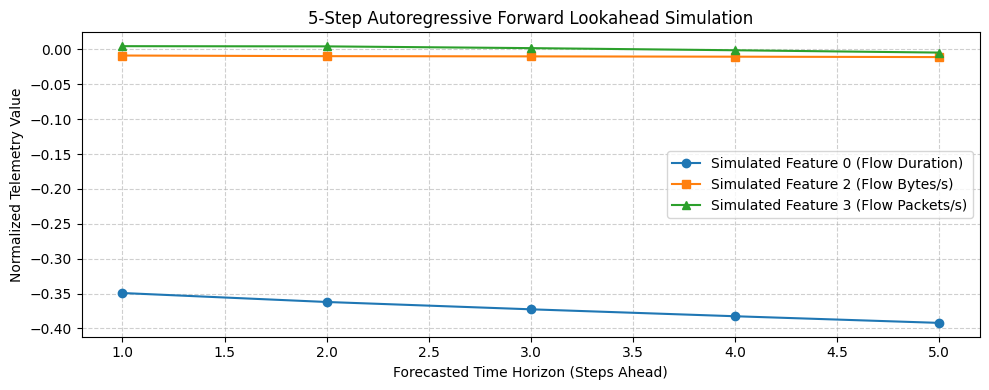

In [9]:
import matplotlib.pyplot as plt
import numpy as np

world_model.eval()

# Select a transition index from the unseen test sequence set
sample_idx = 4500
historical_seq, target_next_true, true_stage, _ = test_dataset[sample_idx]

# Reshape to (1, 20, 16) and move to GPU
current_window = historical_seq.unsqueeze(0).to(device)

K_STEPS = 5
simulated_states = []
predicted_stages = []

print(f"Executing {K_STEPS}-Step Autoregressive Rollout from Sequence #{sample_idx}...\n")

with torch.no_grad():
    for step in range(K_STEPS):
        # 1. Forward pass: simulate next continuous telemetry and classify threat stage
        pred_next_state, pred_mitre_logits = world_model(current_window)

        predicted_class = torch.argmax(pred_mitre_logits, dim=1).item()
        simulated_states.append(pred_next_state.squeeze(0).cpu().numpy())
        predicted_stages.append(predicted_class)

        # 2. Autoregressive feedback loop:
        # Drop oldest step (index 0) and append the newly simulated step to the end
        next_step_expanded = pred_next_state.unsqueeze(1)  # Shape: (1, 1, 16)
        current_window = torch.cat([current_window[:, 1:, :], next_step_expanded], dim=1)

stage_labels = {0: "Normal", 1: "Recon/PortScan", 2: "C2", 3: "Impact/DDoS"}
print("=== MULTI-STEP SIMULATION ROLLOUT TRAJECTORY ===")
for step_num, (stage, state_vec) in enumerate(zip(predicted_stages, simulated_states), start=1):
    print(f"Step t+{step_num}: Predicted MITRE Stage -> {stage_labels.get(stage, f'Stage {stage}')} "
          f"| Simulated State Mean: {state_vec.mean():.4f}")

# Plot simulated continuous state evolution across the 5 future steps
simulated_arr = np.array(simulated_states)
plt.figure(figsize=(10, 4))
plt.plot(range(1, K_STEPS + 1), simulated_arr[:, 0], marker='o', label='Simulated Feature 0 (Flow Duration)')
plt.plot(range(1, K_STEPS + 1), simulated_arr[:, 2], marker='s', label='Simulated Feature 2 (Flow Bytes/s)')
plt.plot(range(1, K_STEPS + 1), simulated_arr[:, 3], marker='^', label='Simulated Feature 3 (Flow Packets/s)')
plt.title(f"{K_STEPS}-Step Autoregressive Forward Lookahead Simulation")
plt.xlabel("Forecasted Time Horizon (Steps Ahead)")
plt.ylabel("Normalized Telemetry Value")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

Located active Attack/DDoS sequence at index: 0

=== ATTACK TRAJECTORY SIMULATION ===
Step t+1: Predicted MITRE Stage -> Impact/DDoS | Simulated State Mean: 0.6843
Step t+2: Predicted MITRE Stage -> Impact/DDoS | Simulated State Mean: 0.1071
Step t+3: Predicted MITRE Stage -> Impact/DDoS | Simulated State Mean: 0.6662
Step t+4: Predicted MITRE Stage -> Impact/DDoS | Simulated State Mean: 0.1119
Step t+5: Predicted MITRE Stage -> Impact/DDoS | Simulated State Mean: 0.6616


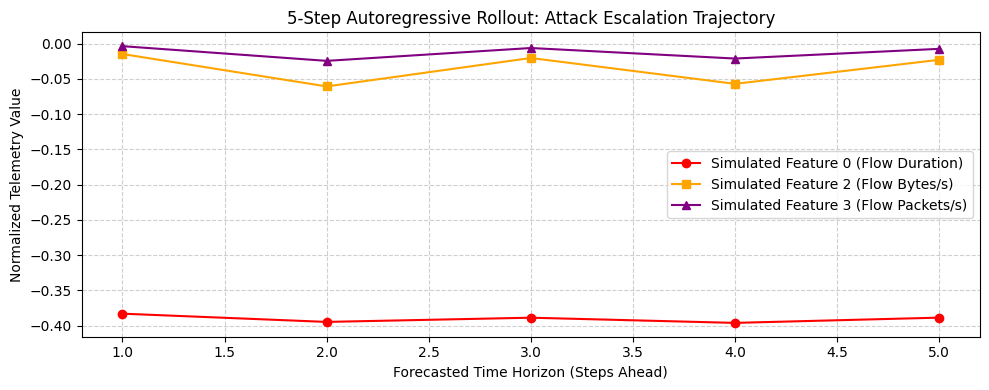

In [10]:
# 1. Automatically locate a sequence where DDoS impact begins
target_idx = None
for idx in range(len(test_dataset)):
    _, _, stage, _ = test_dataset[idx]
    if stage.item() == 3:  # Stage 3: Impact/DDoS
        target_idx = idx
        break

print(f"Located active Attack/DDoS sequence at index: {target_idx}")

# 2. Extract the attack sequence
historical_seq, _, true_stage, _ = test_dataset[target_idx]
current_window = historical_seq.unsqueeze(0).to(device)

K_STEPS = 5
simulated_states = []
predicted_stages = []

with torch.no_grad():
    for step in range(K_STEPS):
        pred_next_state, pred_mitre_logits = world_model(current_window)

        predicted_class = torch.argmax(pred_mitre_logits, dim=1).item()
        simulated_states.append(pred_next_state.squeeze(0).cpu().numpy())
        predicted_stages.append(predicted_class)

        # Autoregressive feedback: shift window left, append simulated vector
        next_step_expanded = pred_next_state.unsqueeze(1)
        current_window = torch.cat([current_window[:, 1:, :], next_step_expanded], dim=1)

stage_labels = {0: "Normal", 1: "Recon/PortScan", 2: "C2", 3: "Impact/DDoS"}
print("\n=== ATTACK TRAJECTORY SIMULATION ===")
for step_num, (stage, state_vec) in enumerate(zip(predicted_stages, simulated_states), start=1):
    print(f"Step t+{step_num}: Predicted MITRE Stage -> {stage_labels.get(stage, f'Stage {stage}')} "
          f"| Simulated State Mean: {state_vec.mean():.4f}")

# 3. Plot attack dynamics rollout
simulated_arr = np.array(simulated_states)
plt.figure(figsize=(10, 4))
plt.plot(range(1, K_STEPS + 1), simulated_arr[:, 0], marker='o', color='red', label='Simulated Feature 0 (Flow Duration)')
plt.plot(range(1, K_STEPS + 1), simulated_arr[:, 2], marker='s', color='orange', label='Simulated Feature 2 (Flow Bytes/s)')
plt.plot(range(1, K_STEPS + 1), simulated_arr[:, 3], marker='^', color='purple', label='Simulated Feature 3 (Flow Packets/s)')
plt.title(f"{K_STEPS}-Step Autoregressive Rollout: Attack Escalation Trajectory")
plt.xlabel("Forecasted Time Horizon (Steps Ahead)")
plt.ylabel("Normalized Telemetry Value")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

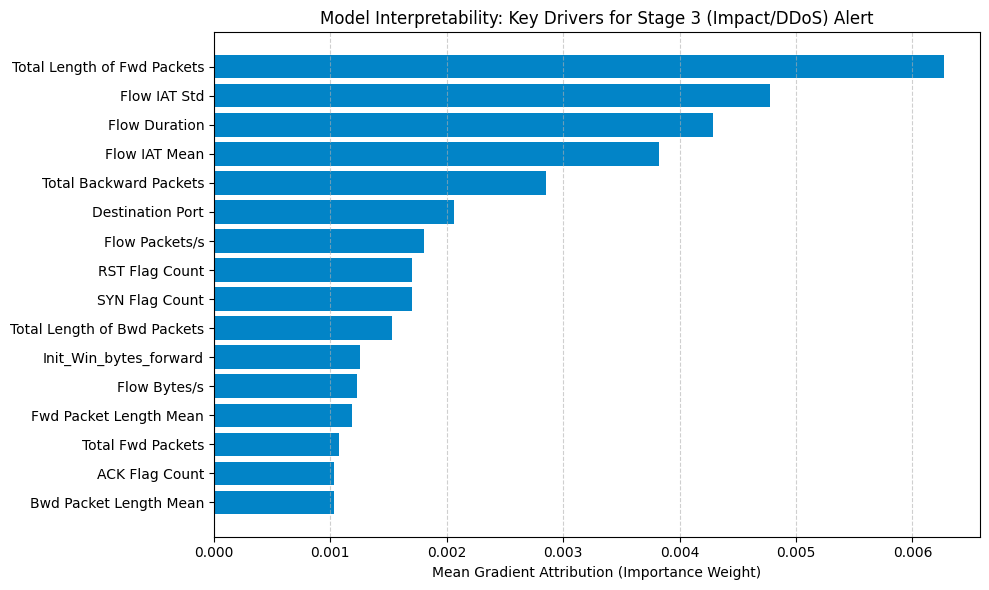


Top 5 Most Critical Features Driving This Alert:
                    Feature  Importance
Total Length of Fwd Packets    0.006267
               Flow IAT Std    0.004776
              Flow Duration    0.004284
              Flow IAT Mean    0.003823
     Total Backward Packets    0.002850


In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Keep in train mode for cuDNN backward, but disable dropout layers manually
world_model.train()
for m in world_model.modules():
    if isinstance(m, nn.Dropout):
        m.eval()

# 2. Prepare attack sequence input
input_seq = historical_seq.unsqueeze(0).to(device).clone().detach()
input_seq.requires_grad_(True)

# 3. Forward pass through classifier head
world_model.zero_grad()
_, logits = world_model(input_seq)
target_class = torch.argmax(logits, dim=1).item()

# 4. Backward pass to calculate input saliency gradients
logits[0, target_class].backward()

# 5. Extract absolute gradients averaged across the 20 sequence steps
gradients = input_seq.grad.abs().squeeze(0).mean(dim=0).detach().cpu().numpy()

# 16 selected features
feature_names = [
    "Destination Port", "Flow Duration", "Flow Bytes/s", "Flow Packets/s",
    "Total Fwd Packets", "Total Backward Packets", "Total Length of Fwd Packets",
    "Total Length of Bwd Packets", "Fwd Packet Length Mean", "Bwd Packet Length Mean",
    "Flow IAT Mean", "Flow IAT Std", "SYN Flag Count", "ACK Flag Count",
    "RST Flag Count", "Init_Win_bytes_forward"
]

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": gradients
}).sort_values(by="Importance", ascending=True)

# 6. Plot Feature Importance Saliency Map
plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"], importance_df["Importance"], color="#0284c7")
plt.title(f"Model Interpretability: Key Drivers for Stage {target_class} ({stage_labels[target_class]}) Alert")
plt.xlabel("Mean Gradient Attribution (Importance Weight)")
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

print("\nTop 5 Most Critical Features Driving This Alert:")
print(importance_df.tail(5)[::-1].to_string(index=False))

In [13]:
import pickle
import numpy as np

# 1. Export sample sequences (first 200 sequences of test set) for real-time dashboard replay
export_samples = []
export_labels = []
export_targets = []

for i in range(min(200, len(test_dataset))):
    seq, target_next, stage, _ = test_dataset[i]
    export_samples.append(seq.numpy())
    export_targets.append(target_next.numpy())
    export_labels.append(stage.item())

np.savez_compressed(
    "dashboard_test_stream.npz",
    sequences=np.array(export_samples),
    targets=np.array(export_targets),
    labels=np.array(export_labels)
)

print("Project artifacts ready:")
print("1. Model Weights   -> network_world_model.pth")
print("2. Normalizer      -> scaler.pkl")
print("3. Telemetry Stream -> dashboard_test_stream.npz")

Project artifacts ready:
1. Model Weights   -> network_world_model.pth
2. Normalizer      -> scaler.pkl
3. Telemetry Stream -> dashboard_test_stream.npz
